In [1]:
import pandas as pd 
import numpy as np


In [2]:
df1 = pd.read_excel("D:/retail_project_1/data/raw/online_retail_II.xlsx",sheet_name="Year 2009-2010")
df2 = pd.read_excel("D:/retail_project_1/data/raw/online_retail_II.xlsx",sheet_name="Year 2010-2011")


df = pd.concat([df1,df2], ignore_index=True)

In [3]:
df.shape

(1067371, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("from", df["InvoiceDate"].min())
print("to", df["InvoiceDate"].max())

from 2009-12-01 07:45:00
to 2011-12-09 12:50:00


In [15]:
df["Invoice"] = df["Invoice"].astype(str)
cancellations = df[df['Invoice'].str.startswith('C')]
print("\nCancellations:", len(cancellations))


Cancellations: 19494


In [21]:
print("Unique Products:", df["StockCode"].nunique())
print("Unique Customer IDs:", df["Customer ID"].nunique())
print("Unique Countries:", df["Country"].nunique())

Unique Products: 5305
Unique Customer IDs: 5942
Unique Countries: 43


EDA

How did the company revenue change over time?

In [27]:
df["total_price"] = (df["Quantity"] * df["Price"])
df["total_price"].head()

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: total_price, dtype: float64

In [29]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["total_price"].sum().reset_index()
)

In [30]:
import matplotlib.pyplot as plt

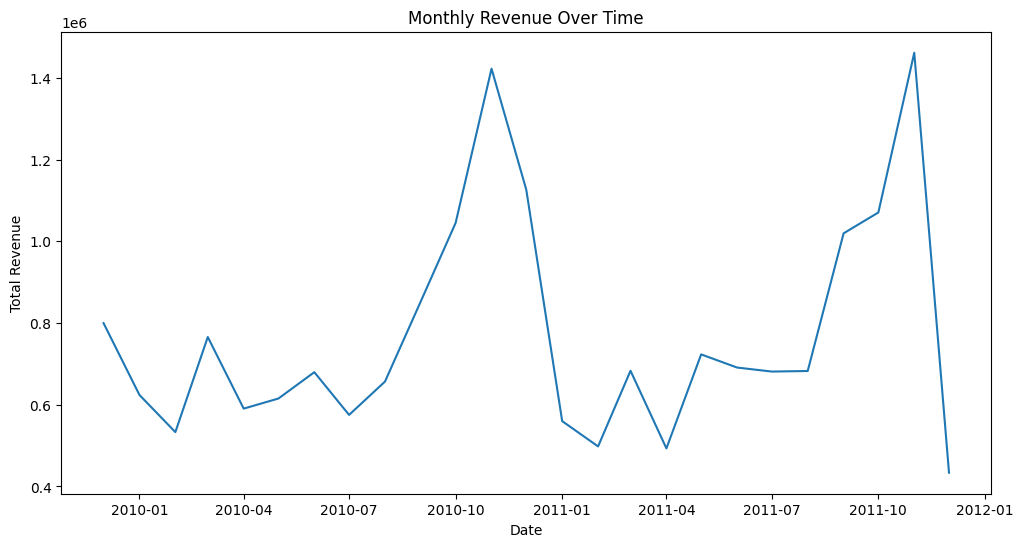

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["InvoiceDate"].dt.to_timestamp(), monthly_revenue["total_price"])  
plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

Insights:
1. Revenue shows strong seasonal spikes during late-year holiday periods.
2. 2011 revenue generally exceeds 2010 revenue, indicating business growth.
3. The sharp decline in December 2011 is likely due to incomplete monthly data because the dataset ends before the month completed.

Where are customers coming from?

In [42]:
df_top_countries = (df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10))

In [44]:
df_top_countries

Country
United Kingdom    49108
Germany            1095
EIRE                806
France              746
Netherlands         250
Spain               188
Belgium             183
Sweden              129
Portugal            124
Switzerland         123
Name: Invoice, dtype: int64

Text(0, 0.5, 'Number of Transactions')

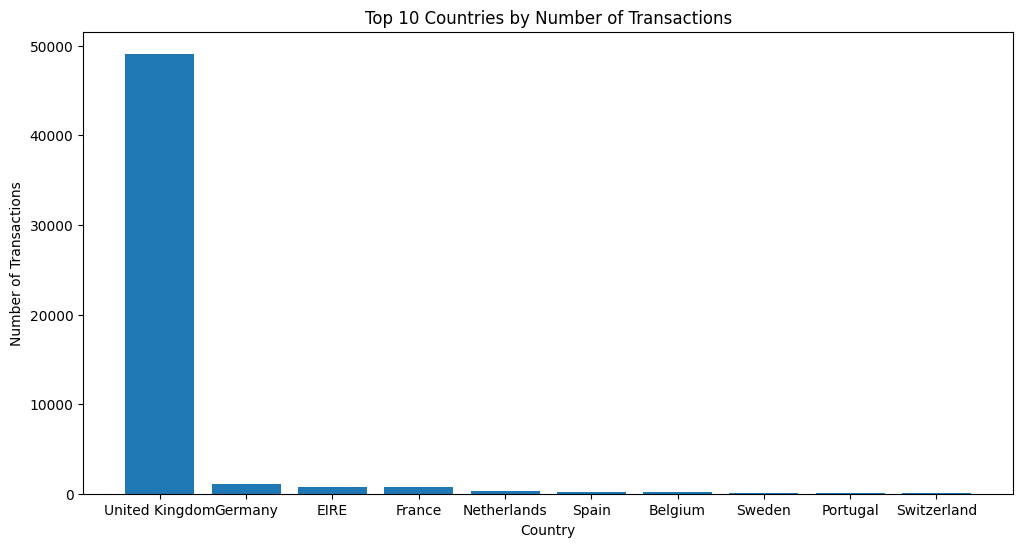

In [43]:
plt.figure(figsize=(12, 6))
plt.bar(df_top_countries.index, df_top_countries.values)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

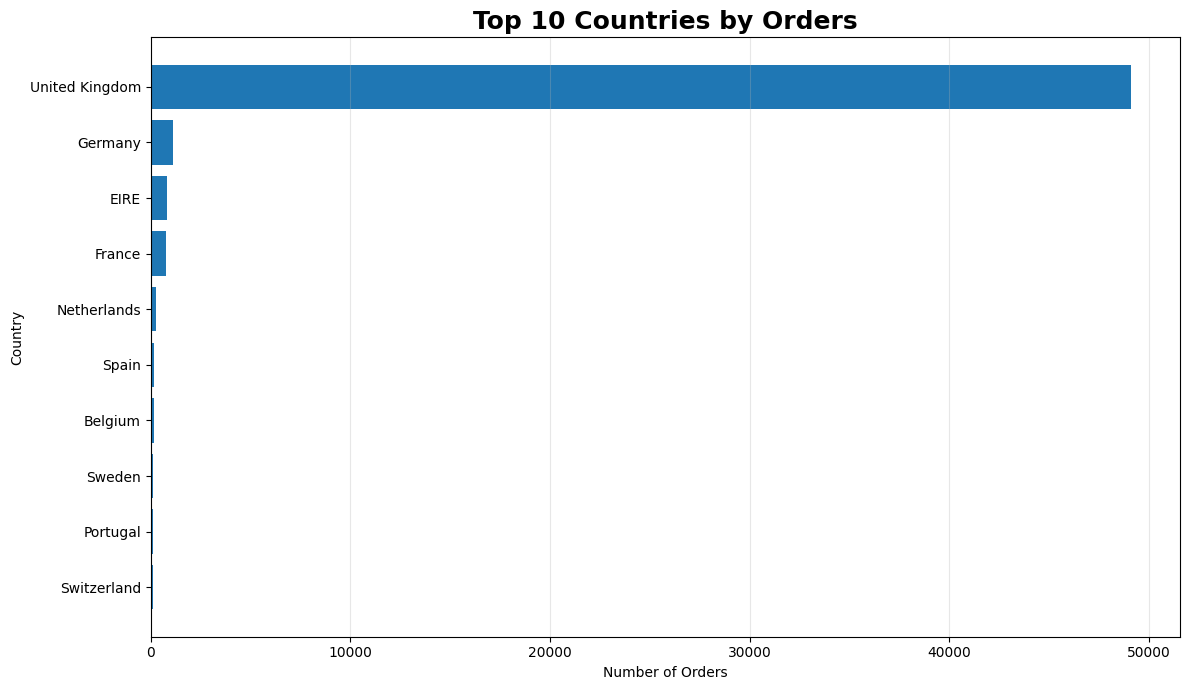

In [46]:
plt.figure(figsize=(12,7))

plt.barh(
    df_top_countries.index,
    df_top_countries.values
)

plt.title(
    "Top 10 Countries by Orders",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Orders")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

Insight:
The United Kingdom overwhelmingly dominates transaction volume, contributing the vast majority of orders. This validates restricting the churn analysis to UK customers for a cleaner and more reliable behavioral model. After excluding the UK, Germany, EIRE, and France emerge as the strongest international markets.

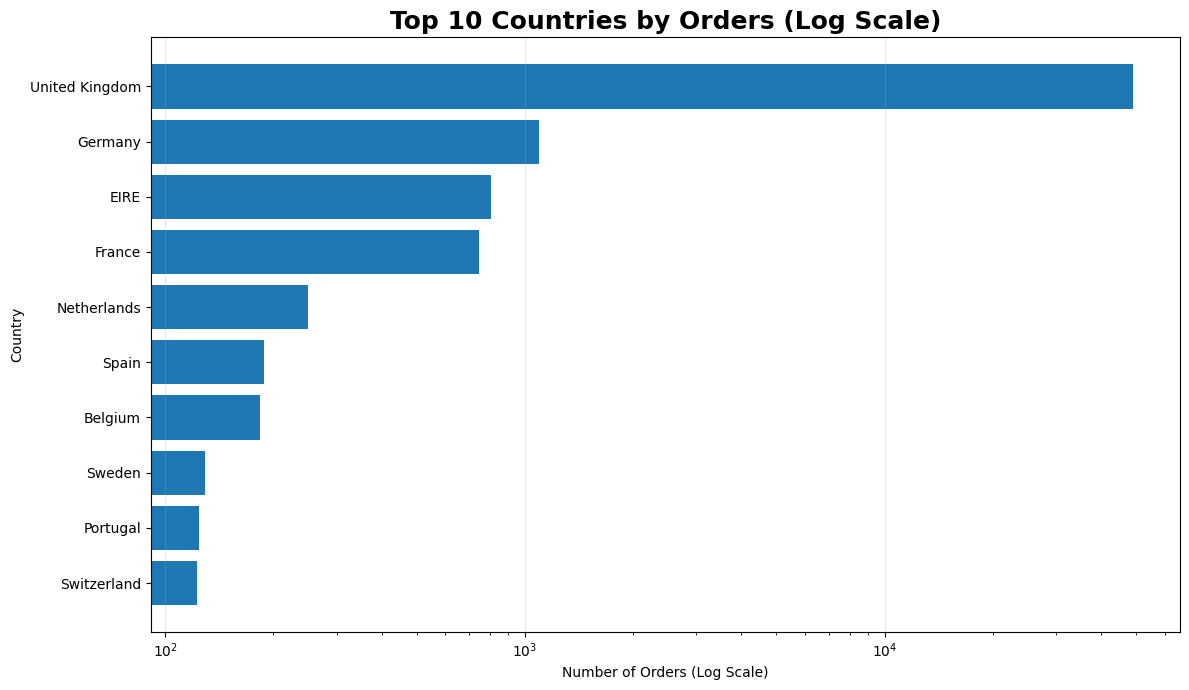

In [47]:
plt.figure(figsize=(12,7))

plt.barh(
    df_top_countries.index,
    df_top_countries.values
)

plt.xscale("log")

plt.title(
    "Top 10 Countries by Orders (Log Scale)",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Orders (Log Scale)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

Are cancellations increasing or decreasing?

In [48]:
cancellations_overtime =cancellations.groupby(cancellations["InvoiceDate"].dt.to_period("M"))["Invoice"].nunique().reset_index()

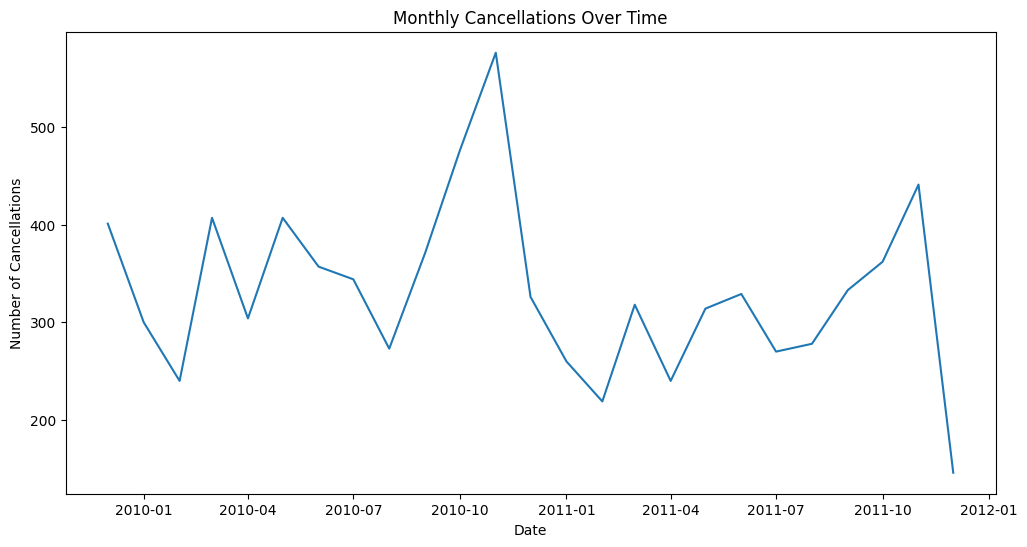

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(cancellations_overtime["InvoiceDate"].dt.to_timestamp(), cancellations_overtime["Invoice"])
plt.title("Monthly Cancellations Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cancellations")
plt.show()